In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from skimage.filters import frangi, threshold_otsu, apply_hysteresis_threshold
from skimage.morphology import closing, opening, disk, remove_small_objects
from skimage.exposure import equalize_adapthist
from sklearn.metrics import jaccard_score, f1_score, accuracy_score, confusion_matrix

DATA_DIR = Path.cwd() / "data"
ORIGINAL_DIR = DATA_DIR / "original"
LABELS_DIR = DATA_DIR / "labels"


In [17]:
def split_channels(image: np.ndarray):
    """Return R, G, B channels from RGB image."""
    return image[:, :, 0], image[:, :, 1], image[:, :, 2]

In [18]:
def load_image(path: Path) -> np.ndarray:
    return np.array(Image.open(path))


def load_label(path: Path) -> np.ndarray:
    lbl = np.array(Image.open(path))
    return (lbl > 0).astype(np.uint8)

In [96]:
def create_foreground_mask(image: np.ndarray, threshold: int = 30) -> np.ndarray:
    """Binary mask: True where sum(RGB) > threshold (eye region)."""
    return np.sum(image, axis=2) > threshold


def apply_mask(data: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Zero out pixels outside mask."""
    return data * mask


def create_retinal_mask_convex_hull(image_rgb: np.ndarray) -> np.ndarray:
    """
    Advanced retinal mask using convex hull + morphological closing.
    Best for images with irregular dark corners. Prevents edge artifacts in Frangi.
    """
    red = image_rgb[:, :, 0]
    red_blur = cv2.medianBlur(red, 9)

    # Adaptive thresholding
    binary = cv2.adaptiveThreshold(
        red_blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        51,  # block size
        15   # constant
    )

    # Find largest contour (retina circular area)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.ones_like(binary, dtype=bool)

    largest_contour = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(largest_contour)

    # Draw and close hull
    mask = np.zeros_like(binary, dtype=np.uint8)
    cv2.drawContours(mask, [hull], -1, 255, -1)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Erode slightly to clean edge artifacts and prevent boundary false positives
    mask = cv2.erode(mask, kernel, iterations=1)

    return mask > 0


In [35]:
from skimage.filters import gaussian
import cv2

def apply_clahe(
    green: np.ndarray,
    mask: np.ndarray,
    clip_limit: float = 0.03,
    nbins: int = 256,
    kernel = None
) -> np.ndarray:
    """Apply CLAHE to green channel within foreground mask."""
    green_blurred = gaussian(green, sigma=2)
    # Fix: do NOT divide by 255.0 again since skimage.filters.gaussian converts uint8 to float [0, 1]
    normalized = green_blurred.astype(float)
    normalized[~mask] = 0
    enhanced = equalize_adapthist(normalized, kernel_size=kernel, clip_limit=clip_limit, nbins=nbins)
    enhanced[~mask] = 0
    return enhanced


def preprocess_image(image, mask, *, clip_limit = 0.02, nbins = 256, kernel = 64, gauss: tuple[int, int] = (51, 51)):
    if isinstance(image, (str, Path)):
        img = np.array(Image.open(image)).astype(np.uint8)
    else:
        img = image.astype(np.uint8)

    img = cv2.medianBlur(img, 5)

    # Use a larger kernel (51, 51) to estimate only large-scale background illumination variation
    bg_map = cv2.GaussianBlur(img, gauss, 0)
    flat_bg = cv2.subtract(bg_map, img)
    flat_bg = np.clip(flat_bg, 0, 255).astype(np.uint8)

    flat_bg = cv2.medianBlur(flat_bg, 5)
    clahe = apply_clahe(flat_bg, mask=mask, clip_limit=clip_limit, nbins=nbins, kernel=kernel)
    return clahe


In [21]:
def frangi_vesselness(
    image: np.ndarray,
    sigmas: tuple = (1, 2, 3),
    alpha: float = 0.5,
    beta: float = 0.5,
    gamma: float = None,  # Fix: Default gamma to None so skimage automatically computes it
    scale_step=2,
    black_ridges: bool = True,
) -> np.ndarray:
    """Apply Frangi vesselness filter. Returns vessel probability map."""
    return frangi(image, sigmas=sigmas, alpha=alpha, beta=beta, gamma=gamma, black_ridges=black_ridges, scale_step=scale_step)


4


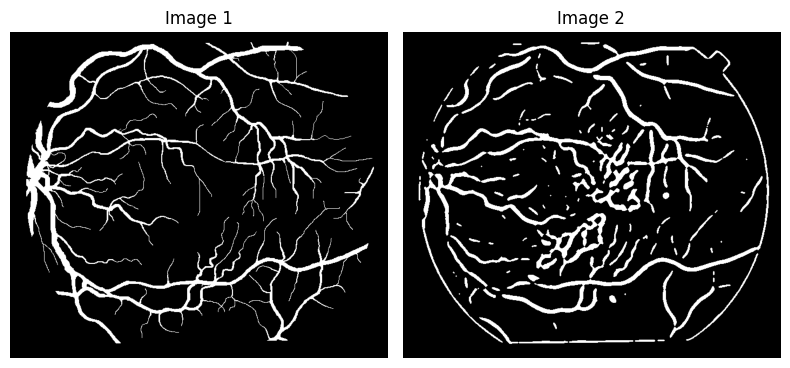

In [97]:
def extract_veins(
    image: np.ndarray,
    sigmas: tuple = (0.5, 1, 1.5, 2, 2.5, 3),
    clip_limit: float = 0.02,
    alpha: float = 0.5,
    beta: float = 0.5,
    gamma: float = None,  # Fix: Default gamma to None
) -> np.ndarray:
    """Extract veins from eye image. Returns binary vein mask."""
    _, green, _ = split_channels(image)
    fg_mask = create_retinal_mask_convex_hull(image)

    enhanced = preprocess_image(green, fg_mask, clip_limit=clip_limit, kernel=64, gauss=(51, 51))
    
    # Fix: vessels are bright in flat_bg, so black_ridges=False
    vesselness = frangi_vesselness(enhanced, sigmas=sigmas, alpha=alpha, beta=beta, gamma=gamma, black_ridges=False, scale_step=None)
    vesselness_masked = apply_mask(vesselness, fg_mask)

    # Fix: scaled threshold to capture thin vessels
    thresh = threshold_otsu(vesselness_masked[fg_mask])
    binary = vesselness_masked > thresh * 0.30

    binary = closing(binary, disk(1))
    binary = remove_small_objects(binary, min_size=20)

    return binary.astype(np.uint8)


img = load_image(ORIGINAL_DIR / f"im0001.ppm")
orig = load_image(LABELS_DIR / f"im0001.vk.ppm")
r = extract_veins(img)
display_images(orig, r)


In [23]:
def evaluate(pred: np.ndarray, gold: np.ndarray) -> dict:
    """Compute evaluation metrics between prediction and gold standard."""
    p_flat = pred.ravel()
    g_flat = gold.ravel()

    return {
        "accuracy": accuracy_score(g_flat, p_flat),
        "f1": f1_score(g_flat, p_flat, zero_division=0),
        "iou": jaccard_score(g_flat, p_flat, zero_division=0),
        "tn": int(confusion_matrix(g_flat, p_flat).ravel()[0]),
        "fp": int(confusion_matrix(g_flat, p_flat).ravel()[1]),
        "fn": int(confusion_matrix(g_flat, p_flat).ravel()[2]),
        "tp": int(confusion_matrix(g_flat, p_flat).ravel()[3]),
    }

In [24]:
def display_images(*images, titles=None, cmap="gray", figsize_per_image=(4, 4)):
    """Display 1..N images in a horizontal row."""
    n = len(images)
    if n == 0:
        print("No images to display.")
        return
    if titles is None:
        titles = [f"Image {i + 1}" for i in range(n)]
    elif len(titles) != n:
        raise ValueError(f"{n} images but {len(titles)} titles")

    fig, axes = plt.subplots(1, n, figsize=(figsize_per_image[0] * n, figsize_per_image[1]))
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [25]:
# Note: create_retinal_mask_convex_hull was moved to Cell 3 to allow top-to-bottom execution.


In [36]:
import cv2
from skimage.morphology import remove_small_objects
from skimage.filters import gaussian, apply_hysteresis_threshold

def normalize_and_remove_bright(image: np.ndarray, percentile: float = 95) -> np.ndarray:
    """Clips pixel intensities above a certain percentile to remove bright fragments
    and normalizes the remaining intensities to the range [0, 255].
    """
    threshold = np.percentile(image, percentile)
    clipped = np.minimum(image, threshold)

    img_min = clipped.min()
    img_max = clipped.max()

    normalized = (clipped - img_min) / (img_max - img_min + 1e-7)
    return (normalized * 255).astype(np.uint8)

def process_one(image_id: str, tests: list[dict] = None) -> dict:
    """Load, extract veins, evaluate for a single image. Supports grid search if tests is provided."""
    img = load_image(ORIGINAL_DIR / f"{image_id}.ppm")
    gold = load_label(LABELS_DIR / f"{image_id}.vk.ppm")

    red, green, blue = split_channels(img)
    fg_mask = create_retinal_mask_convex_hull(img)
    fg_mask = fg_mask > 0

    if tests is not None:
        enhanced = preprocess_image(green, fg_mask)
        result = []
        for t in tests:
            print("Trying", t)
            # Fix: black_ridges=False, gamma=None
            vesselness = frangi_vesselness(enhanced, sigmas=t.get("sigmas"), alpha=0.5, beta=0.5, gamma=None, black_ridges=False)
            vesselness_masked = apply_mask(vesselness, fg_mask)

            thresh = threshold_otsu(vesselness_masked[fg_mask])
            pred = vesselness_masked > (thresh * 0.30)
            pred = closing(pred, disk(1))
            pred = remove_small_objects(pred, min_size=20)
            result.append((t, pred.astype(np.uint8)))

        return {
            "image_id": image_id,
            "image": img,
            "gold": gold,
            "red": red,
            "green": green,
            "blue": blue,
            "enhanced": enhanced,
            "vesselness": vesselness,
            "masked": vesselness_masked,
            "result": result,
        }
    else:
        # Optimized default run that computes metrics to support evaluation in subsequent cells
        pred = extract_veins(img)
        metrics = evaluate(pred, gold)

        enhanced = preprocess_image(green, fg_mask, gauss=(51, 51), kernel=64)
        vesselness = frangi_vesselness(enhanced, sigmas=(0.5, 1, 1.5, 2, 2.5, 3), black_ridges=False, gamma=None)
        vesselness_masked = apply_mask(vesselness, fg_mask)

        return {
            "image_id": image_id,
            "image": img,
            "gold": gold,
            "pred": pred,
            "vesselness": vesselness_masked,
            "enhanced": enhanced,
            **metrics,
        }


Trying {'sigmas': (3, 100)}


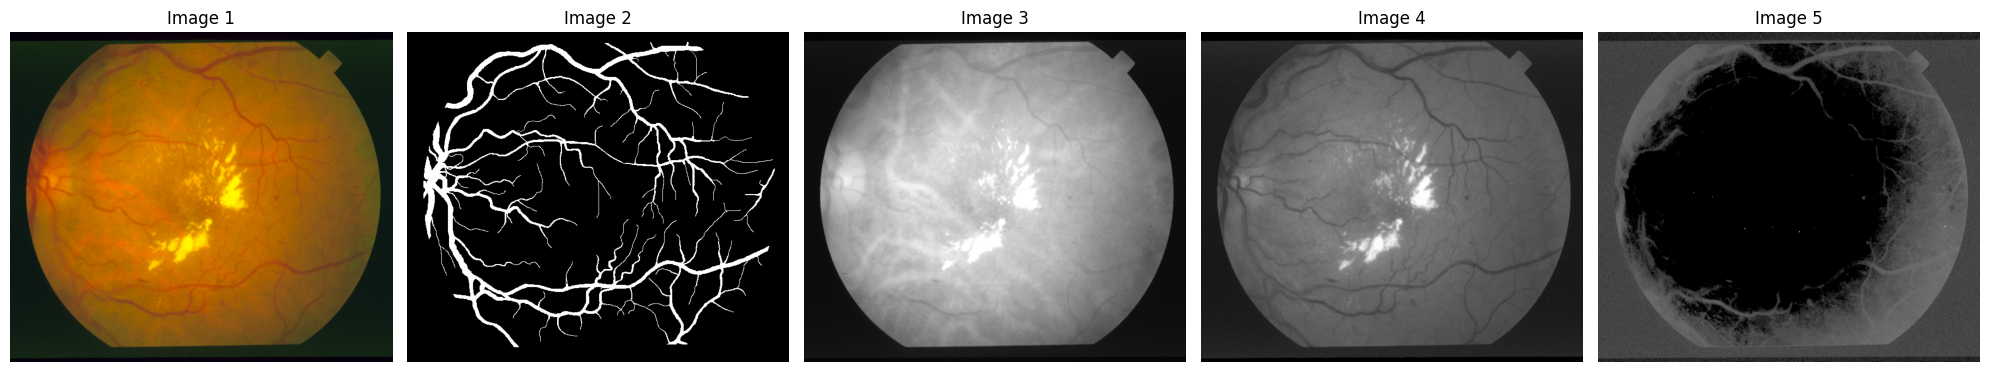

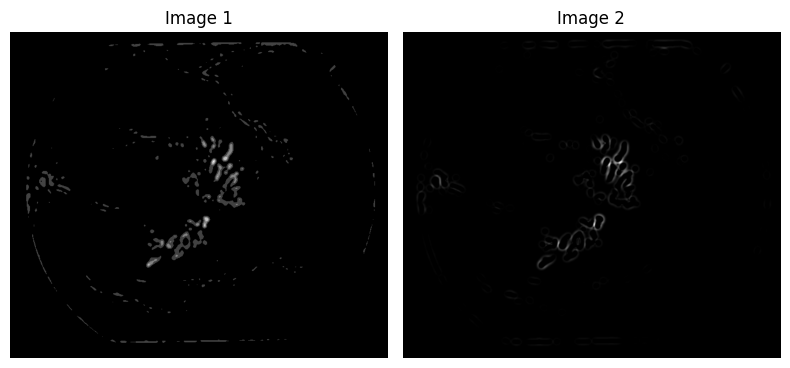

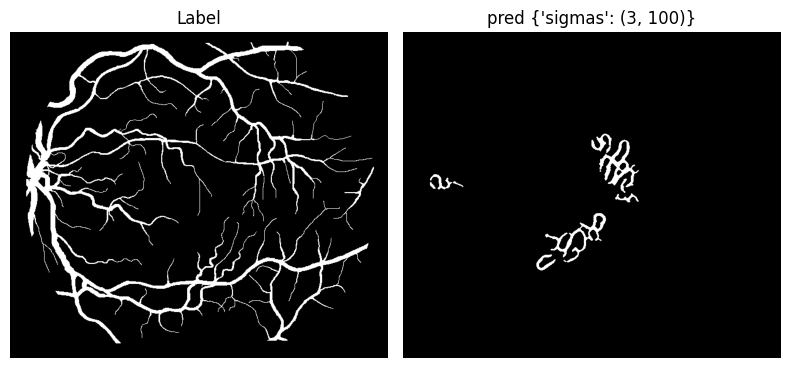

In [33]:
r = process_one("im0001", [
    # {"sigmas": (0.1, 0.5)},
    # {"sigmas": (1, 20)},
    # {"sigmas": (1, 50)},
    # {"sigmas": (1, 100)},
    # {"sigmas": (2, 10)},
    # {"sigmas": (2, 20)},
    # {"sigmas": (2, 50)},
    # {"sigmas": (2, 100)},
    # {"sigmas": (3, 10)},
    # {"sigmas": (3, 20)},
    # {"sigmas": (3, 50)},
    {"sigmas": (3, 100)},
    # {"sigmas": (4, 10)},
    # {"sigmas": (4, 20)},
    # {"sigmas": (4, 50)},
    # {"sigmas": (4, 100)},
    # {"sigmas": (6, 10)},
    # {"sigmas": (6, 50)},
    # {"sigmas": (6, 100)},
    # {"sigmas": (10, 10)},
    # {"sigmas": (10, 50)},
    # {"sigmas": (10, 100)},
    # {"sigmas": (10, 200)},
])
display_images(r["image"], r["gold"], r["red"], r["green"], r["blue"])
display_images(r["enhanced"], r["vesselness"])

for par, img in r["result"]:
    display_images(r["gold"], img, titles=["Label", f"pred {par}"])


In [28]:
image_ids = sorted([p.stem for p in ORIGINAL_DIR.glob("*.ppm")])
image_ids = list(image_ids)[:1]
print(f"Found {len(image_ids)} images: {image_ids[:5]}...")

Found 1 images: ['im0001']...


In [29]:
results = []
for img_id in image_ids:
    r = process_one(img_id)
    results.append(r)
    print(f"{img_id}: acc={r['accuracy']:.3f}  f1={r['f1']:.3f}  iou={r['iou']:.3f}")

TypeError: process_one() missing 1 required positional argument: 'tests'

In [ ]:
df = pd.DataFrame(results)
df[["image_id", "accuracy", "f1", "iou", "tp", "fp", "fn", "tn"]]

In [ ]:
print(f"Mean accuracy: {df['accuracy'].mean():.3f}")
print(f"Mean F1:       {df['f1'].mean():.3f}")
print(f"Mean IoU:      {df['iou'].mean():.3f}")

In [ ]:
best_idx = df["f1"].idxmax()
worst_idx = df["f1"].idxmin()

visualize(
    results[best_idx]["image"],
    results[best_idx]["gold"],
    results[best_idx]["pred"],
    results[best_idx]["vesselness"],
    results[best_idx]["enhanced"],
    title=f"Best: {results[best_idx]['image_id']}  F1={results[best_idx]['f1']:.3f}",
)

In [ ]:
visualize(
    results[worst_idx]["image"],
    results[worst_idx]["gold"],
    results[worst_idx]["pred"],
    results[worst_idx]["vesselness"],
    results[worst_idx]["enhanced"],
    title=f"Worst: {results[worst_idx]['image_id']}  F1={results[worst_idx]['f1']:.3f}",
)